# Next-Day Volatility Forecasting (Baseline)

This notebook builds a baseline model for next-day stock-level volatility using:
- `CTVA`
- `DDOG`

Baseline rule:
- Predict next-day `volatility_1D` as today's `volatility_1D` (persistence baseline).

## Workflow Overview

1. Load and sort data
2. Apply exact split logic
3. Filter to `CTVA` and `DDOG`
4. Engineer minimal baseline features
5. Evaluate on validation
6. Evaluate on unseen (sequential, no refit)
7. Report metrics and plots

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")

## Paths and Config

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"
unseen_path = "data/sp500_unseen.csv"

symbols_to_model = ["CTVA", "DDOG"]

print("csv_path:", csv_path)
print("unseen_path:", unseen_path)
print("symbols:", symbols_to_model)

csv_path: data/sp500_5yr_with_sectors_weights.csv
unseen_path: data/sp500_unseen.csv
symbols: ['CTVA', 'DDOG']


## Load Data

In [3]:
df = pd.read_csv(csv_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).copy()

unseen_reference = pd.read_csv(unseen_path)
unseen_reference["Date"] = pd.to_datetime(unseen_reference["Date"])
unseen_reference = unseen_reference.sort_values(["Symbol", "Date"]).copy()

print("Main shape:", df.shape)
print("Unseen reference shape:", unseen_reference.shape)
display(df.head(3))

Main shape: (626169, 10)
Unseen reference shape: (125248, 10)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005


## Exact Date Split Logic (As Requested)

In [4]:
unseen_end = df['Date'].max().normalize()
unseen_start = unseen_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
val_end = unseen_start - pd.Timedelta(days=1)
val_start = val_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
train_end = val_start - pd.Timedelta(days=1)
data_start = train_end - pd.DateOffset(years=3) + pd.Timedelta(days=1)

print("data_start   :", data_start.date())
print("train_end    :", train_end.date())
print("val_start    :", val_start.date())
print("val_end      :", val_end.date())
print("unseen_start :", unseen_start.date())
print("unseen_end   :", unseen_end.date())

data_start   : 2021-03-21
train_end    : 2024-03-20
val_start    : 2024-03-21
val_end      : 2025-03-20
unseen_start : 2025-03-21
unseen_end   : 2026-03-20


## Filter to Target Stocks

In [5]:
df = df[df["Symbol"].isin(symbols_to_model)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

unseen_reference_small = unseen_reference[unseen_reference["Symbol"].isin(symbols_to_model)].copy()
unseen_reference_small = unseen_reference_small.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Filtered main shape:", df.shape)
print("Filtered unseen shape:", unseen_reference_small.shape)

display(
    df.groupby("Symbol")
    .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
    .reset_index()
)

Filtered main shape: (2512, 10)
Filtered unseen shape: (502, 10)


,Symbol,rows,min_date,max_date
0,CTVA,1256,2021-03-22,2026-03-20
1,DDOG,1256,2021-03-22,2026-03-20


## Feature Engineering for Baseline

We compute:
- `log_return_1D = log(Close).diff()`
- `volatility_1D = abs(log_return_1D)`
- `target_next_volatility_1D = next-day volatility_1D`

In [6]:
def add_baseline_features(input_df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for symbol, g in input_df.sort_values(["Symbol", "Date"]).groupby("Symbol", sort=False):
        g = g.copy()
        g["Close"] = g["Close"].astype(float)
        g["log_return_1D"] = np.log(g["Close"]).diff()
        g["volatility_1D"] = g["log_return_1D"].abs()
        g["target_next_volatility_1D"] = g["volatility_1D"].shift(-1)
        parts.append(g)
    out = pd.concat(parts, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)
    return out

## Build Train/Validation and Unseen Sets (Leakage-Safe)

In [7]:
pre_unseen_raw = df[(df["Date"] >= data_start) & (df["Date"] <= val_end)].copy()
unseen_raw = unseen_reference_small[
    (unseen_reference_small["Date"] >= unseen_start) & (unseen_reference_small["Date"] <= unseen_end)
].copy()

pre_unseen_feat = add_baseline_features(pre_unseen_raw)
pre_unseen_model = pre_unseen_feat.dropna(subset=["volatility_1D", "target_next_volatility_1D"]).copy()

train_df = pre_unseen_model[
    (pre_unseen_model["Date"] >= data_start) & (pre_unseen_model["Date"] <= train_end)
].copy()
val_df = pre_unseen_model[
    (pre_unseen_model["Date"] >= val_start) & (pre_unseen_model["Date"] <= val_end)
].copy()

print("pre_unseen_raw shape:", pre_unseen_raw.shape)
print("pre_unseen_model shape:", pre_unseen_model.shape)
print("train_df shape:", train_df.shape)
print("val_df shape  :", val_df.shape)
print("unseen_raw shape:", unseen_raw.shape)

pre_unseen_raw shape: (2010, 10)
pre_unseen_model shape: (2006, 13)
train_df shape: (1508, 13)
val_df shape  : (498, 13)
unseen_raw shape: (502, 10)


## Metrics Helper

In [8]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        corr = np.nan
    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": float(mse),
        "Corr": corr,
        "sMAPE": float(smape(y_true, y_pred)),
    }

## Validation Evaluation (Baseline)

In [9]:
validation_records = []
validation_predictions = []

for symbol in symbols_to_model:
    val_s = val_df[val_df["Symbol"] == symbol].sort_values("Date").copy()

    y_val = val_s["target_next_volatility_1D"].values
    pred_val = val_s["volatility_1D"].values

    metrics = compute_metrics(y_val, pred_val)
    validation_records.append({
        "Stage": "Validation",
        "Symbol": symbol,
        "Model": "Naive(today_vol)",
        **metrics
    })

    p = val_s[["Date", "Symbol", "volatility_1D", "target_next_volatility_1D"]].copy()
    p.rename(columns={"target_next_volatility_1D": "actual"}, inplace=True)
    p["pred_baseline"] = pred_val
    validation_predictions.append(p)

validation_metrics_df = pd.DataFrame(validation_records)
validation_predictions_df = pd.concat(validation_predictions, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Validation metrics:")
display(validation_metrics_df)
print("Validation predictions head:")
display(validation_predictions_df.head(5))

Validation metrics:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Validation,CTVA,Naive(today_vol),0.014867,0.010580,0.000221,-0.032664,95.464999
1,Validation,DDOG,Naive(today_vol),0.022630,0.016269,0.000512,0.122137,91.981621


Validation predictions head:


,Date,Symbol,volatility_1D,actual,pred_baseline
0,2024-03-21,CTVA,0.000897,0.012810,0.000897
1,2024-03-22,CTVA,0.012810,0.010118,0.012810
2,2024-03-25,CTVA,0.010118,0.011972,0.010118
3,2024-03-26,CTVA,0.011972,0.012357,0.011972
4,2024-03-27,CTVA,0.012357,0.011686,0.012357


## Unseen Evaluation (Baseline)

In [10]:
# Add trailing history to ensure first unseen rows have valid derived fields
history_tail_rows = 30
unseen_parts = []

for symbol in symbols_to_model:
    hist_symbol = pre_unseen_raw[pre_unseen_raw["Symbol"] == symbol].sort_values("Date").tail(history_tail_rows)
    unseen_symbol = unseen_raw[unseen_raw["Symbol"] == symbol].sort_values("Date")
    combined = pd.concat([hist_symbol, unseen_symbol], axis=0).sort_values("Date").copy()
    combined["Symbol"] = symbol
    engineered = add_baseline_features(combined)
    engineered = engineered[(engineered["Date"] >= unseen_start) & (engineered["Date"] <= unseen_end)].copy()
    unseen_parts.append(engineered)

unseen_feat = pd.concat(unseen_parts, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)
unseen_model_df = unseen_feat.dropna(subset=["volatility_1D", "target_next_volatility_1D"]).copy()

unseen_records = []
unseen_predictions = []

for symbol in symbols_to_model:
    us = unseen_model_df[unseen_model_df["Symbol"] == symbol].sort_values("Date").copy()
    y_us = us["target_next_volatility_1D"].values
    pred_us = us["volatility_1D"].values

    metrics = compute_metrics(y_us, pred_us)
    unseen_records.append({
        "Stage": "Unseen",
        "Symbol": symbol,
        "Model": "Naive(today_vol)",
        **metrics
    })

    p = us[["Date", "Symbol", "volatility_1D", "target_next_volatility_1D"]].copy()
    p.rename(columns={"target_next_volatility_1D": "actual"}, inplace=True)
    p["pred_baseline"] = pred_us
    unseen_predictions.append(p)

unseen_metrics_df = pd.DataFrame(unseen_records)
unseen_predictions_df = pd.concat(unseen_predictions, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Unseen metrics:")
display(unseen_metrics_df)
print("Unseen predictions head:")
display(unseen_predictions_df.head(5))

Unseen metrics:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Unseen,CTVA,Naive(today_vol),0.016783,0.010460,0.000282,0.070118,92.253878
1,Unseen,DDOG,Naive(today_vol),0.034946,0.021325,0.001221,0.049131,90.301064


Unseen predictions head:


,Date,Symbol,volatility_1D,actual,pred_baseline
0,2025-03-21,CTVA,0.001781,0.005655,0.001781
1,2025-03-24,CTVA,0.005655,0.003551,0.005655
2,2025-03-25,CTVA,0.003551,0.013649,0.003551
3,2025-03-26,CTVA,0.013649,0.004155,0.013649
4,2025-03-27,CTVA,0.004155,0.022349,0.004155


## Plots: Validation Actual vs Baseline

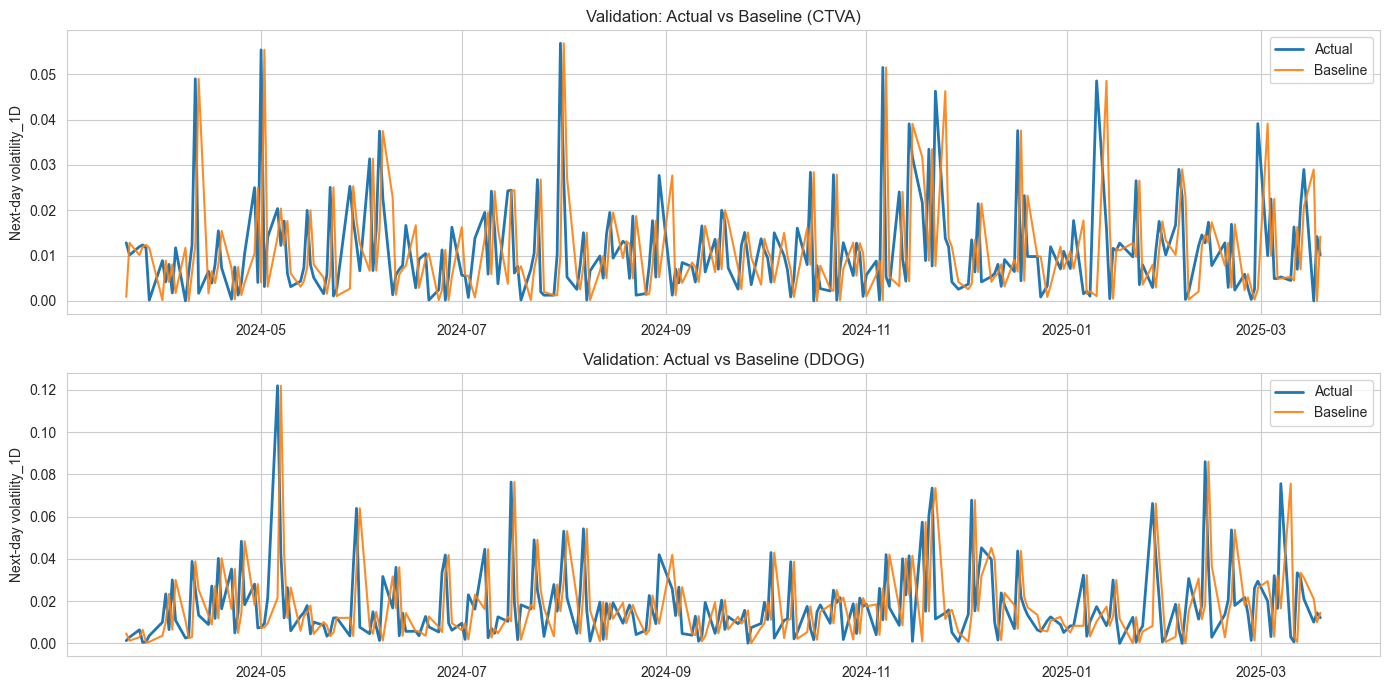

In [11]:
fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 7), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = validation_predictions_df[validation_predictions_df["Symbol"] == symbol]
    ax.plot(p["Date"], p["actual"], label="Actual", linewidth=2)
    ax.plot(p["Date"], p["pred_baseline"], label="Baseline", alpha=0.9)
    ax.set_title(f"Validation: Actual vs Baseline ({symbol})")
    ax.set_ylabel("Next-day volatility_1D")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Plots: Unseen Actual vs Baseline

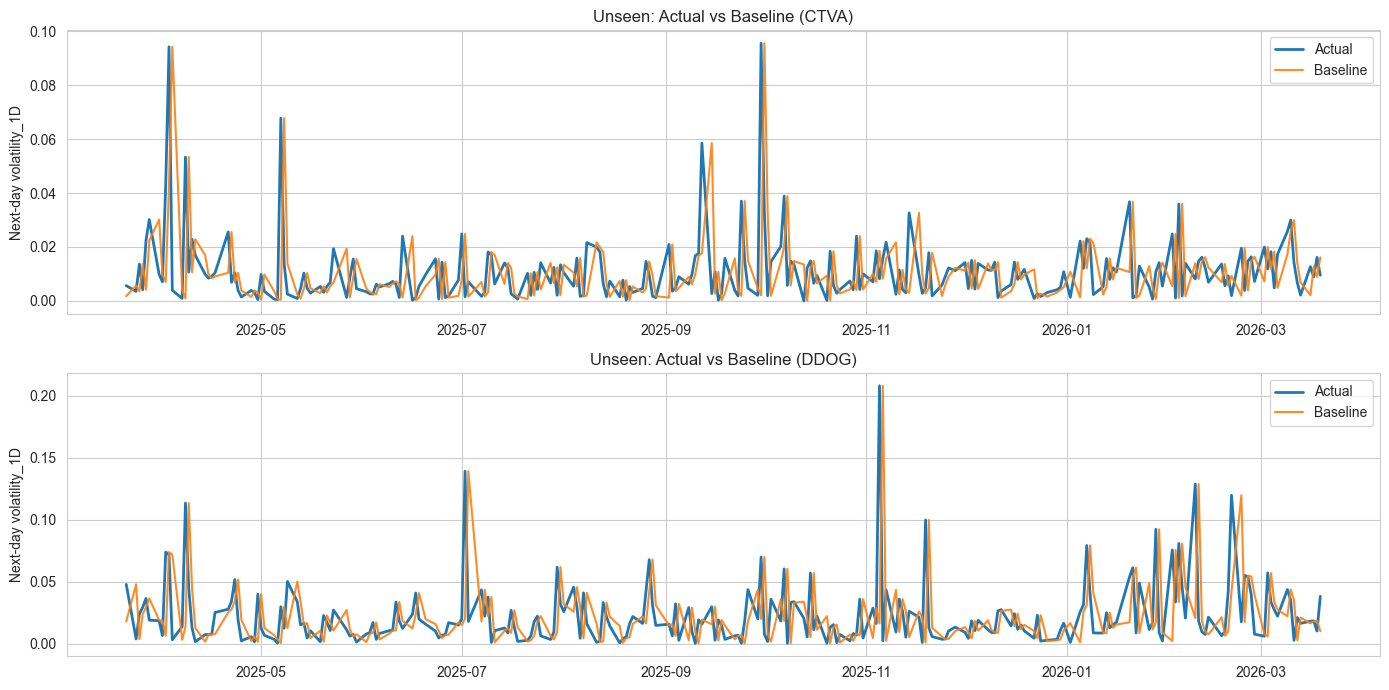

In [12]:
fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 7), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = unseen_predictions_df[unseen_predictions_df["Symbol"] == symbol]
    ax.plot(p["Date"], p["actual"], label="Actual", linewidth=2)
    ax.plot(p["Date"], p["pred_baseline"], label="Baseline", alpha=0.9)
    ax.set_title(f"Unseen: Actual vs Baseline ({symbol})")
    ax.set_ylabel("Next-day volatility_1D")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Plots: Rolling Absolute Error

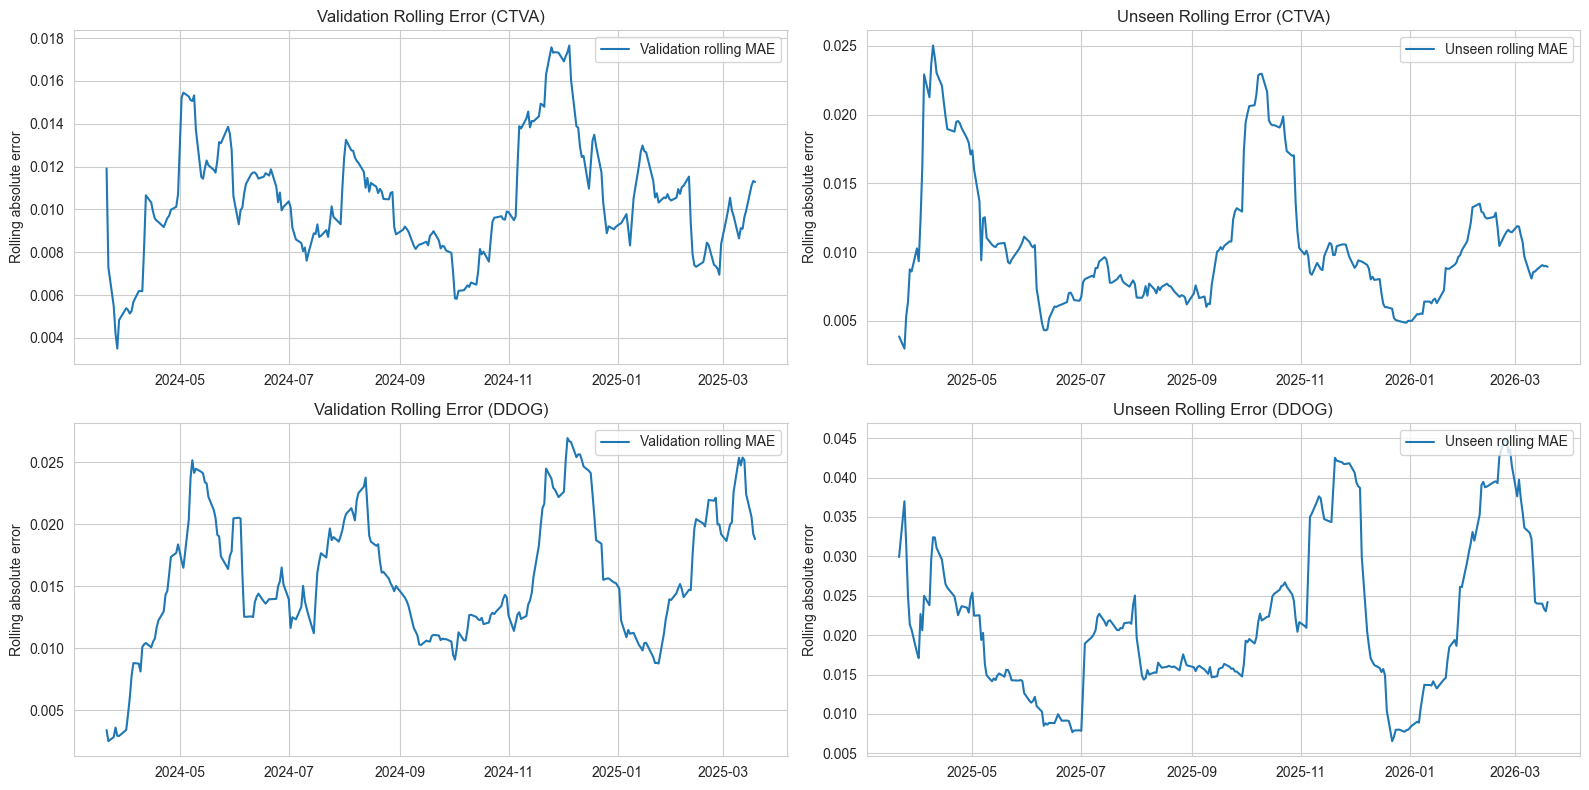

In [13]:
rolling_window = 21

fig, axes = plt.subplots(len(symbols_to_model), 2, figsize=(16, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = np.array([axes])

for r, symbol in enumerate(symbols_to_model):
    pv = validation_predictions_df[validation_predictions_df["Symbol"] == symbol].copy()
    pv["abs_err"] = np.abs(pv["actual"] - pv["pred_baseline"])
    pv["roll_abs_err"] = pv["abs_err"].rolling(rolling_window, min_periods=1).mean()

    pu = unseen_predictions_df[unseen_predictions_df["Symbol"] == symbol].copy()
    pu["abs_err"] = np.abs(pu["actual"] - pu["pred_baseline"])
    pu["roll_abs_err"] = pu["abs_err"].rolling(rolling_window, min_periods=1).mean()

    axes[r, 0].plot(pv["Date"], pv["roll_abs_err"], label="Validation rolling MAE")
    axes[r, 0].set_title(f"Validation Rolling Error ({symbol})")
    axes[r, 0].set_ylabel("Rolling absolute error")
    axes[r, 0].legend(loc="upper right")

    axes[r, 1].plot(pu["Date"], pu["roll_abs_err"], label="Unseen rolling MAE")
    axes[r, 1].set_title(f"Unseen Rolling Error ({symbol})")
    axes[r, 1].set_ylabel("Rolling absolute error")
    axes[r, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Metric Summary

In [14]:
all_metrics_df = pd.concat([validation_metrics_df, unseen_metrics_df], axis=0).reset_index(drop=True)
all_metrics_df = all_metrics_df.sort_values(["Stage", "Symbol"]).reset_index(drop=True)

print("All metrics:")
display(all_metrics_df)

print("RMSE pivot:")
display(
    all_metrics_df.pivot_table(
        index=["Stage", "Symbol"],
        columns="Model",
        values="RMSE"
    )
)

All metrics:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Unseen,CTVA,Naive(today_vol),0.016783,0.010460,0.000282,0.070118,92.253878
1,Unseen,DDOG,Naive(today_vol),0.034946,0.021325,0.001221,0.049131,90.301064
2,Validation,CTVA,Naive(today_vol),0.014867,0.010580,0.000221,-0.032664,95.464999
3,Validation,DDOG,Naive(today_vol),0.022630,0.016269,0.000512,0.122137,91.981621


RMSE pivot:


Model              Naive(today_vol)
Stage      Symbol                  
Unseen     CTVA            0.016783
           DDOG            0.034946
Validation CTVA            0.014867
           DDOG            0.022630

## Notes

- This baseline is intentionally simple and interpretable.
- It serves as the benchmark to beat with Random Forest, LSTM, or other models.